# 04. 学習と評価 — 03 の特徴量で 4 モデルを学習し、本番のスコアを再現する

`03_feature_engineering.ipynb` で確かめた特徴量の作り方を読み込み、**4 モデル(LightGBM / XGBoost / CatBoost / RealMLP)を

本番と同じ設定で学習して、OOF AUC を出す**ノートブック。上から順に実行すれば、本番のスコアが再現できる。

## 0.このノートブックの流れ

| 章 | 内容 | 実行時間の目安 |
|---|---|---|
| 1 | 準備(読み込み・fold 分割・本番の予測との照合の仕組み) | 数秒 |
| 2 | LightGBM(46 列) | 約 4 分 |
| 3 | XGBoost(69 列) | 約 8 分 |
| 4 | CatBoost(43 列) | 約 22 分 |
| 5 | RealMLP(39 列) | 約 41 分 |
| 6 | アンサンブルとまとめ(本番のスコアとの照合、最終提出) | 数秒 |
| 7 | Feature Importance(特徴量の重要度。fold 1 を学習し直して確かめる) | 約 7 分 |

**全体で約 75 分**(実測は約 70 分)

- 特徴量は、03 で確かめた作り方(`src/03_feature_engineering_<model>.py` の関数)を読み込んで作る。
  Target Encoding は fold ごとに作り直す必要があるので、5 fold 分をここで作る
- 各モデルの予測は、本番の予測(`oof/oof_<model>.npy`)と行ごとに照合する。**本番の成果物は上書きしない**
- test の予測と提出ファイルは作らない(本番は `src/04_train_and_evaluate_<model>.py` が作る。6 章にコマンド)

## `src/` を読み込む理由と、ノートブックに移さない理由

特徴量を作る関数(`src/03_feature_engineering_<model>.py`)と RealMLP のモデル本体(`src/04_train_and_evaluate_realmlp.py`)は、

**ノートブックに書き写さず `src/` から読み込む**。ファイル名が数字で始まり、そのままでは `import` と書けないので `importlib` を使っている。

ノートブックだけで完結させる方法(03 から列名や特徴量の値を渡す)も検討したが、次のデメリットがあるので採らない。

| デメリット | 内容 |
|---|---|
| 正本が2つになる | 本番(`src/` の .py)とノートブックに同じ処理が並ぶと、片方だけ直したときに黙ってずれる。本番のスコアを再現するという、このノートブックの目的が崩れる |
| 列名だけでは足りない | Target Encoding の値は fold ごとに変わるので、04 は 5 fold 分を作り直す必要がある。03 から列名を受け取っても、値を作る関数は結局 `src/` から読むことになる |
| 値まで渡すと重い | 03 で 4 モデル × 5 fold の特徴量を保存すると、概算で 1〜2GB になり、03 の実行時間も延びる |
| ノートブックのセルに依存する | 03 の 4-4・5-9 の一覧をセルから切り出して読むと、セルの並びや書き方を変えたときに壊れる |
| `docs/features_*.json` は流用できない | 本番の `--dump-features` を実行するたびに上書きされる |

> **クローン・持ち出しの際は、`notebooks/` だけでなく `src/` も必ず含めること。** `src/` がないと、1 章の準備のあとで読み込みに失敗する。
> また `data/` と `oof/` はリポジトリに含めていない。クローン先では `data/` を Kaggle から取得し、本番の照合に使う `oof/oof_<model>.npy` は `src/04_train_and_evaluate_<model>.py` を先に実行して作る(6 章にコマンド)。

## 05(Hyperparameter Tuning)との関係と、パラメータを値で書いている理由

**05 の位置づけ**: `src/05_hyperparameter_tuning.py` は学習コードを持たない。`src/04_train_and_evaluate_<model>.py` を

引数を変えて1本ずつ呼び、OOF AUC を `docs/hyperparameter_tuning_results.csv` に記録するだけの工程。

```
05_hyperparameter_tuning.py ──(引数を変えて呼ぶ)──→ 04_train_and_evaluate_<model>.py ──→ OOF AUC
        └──→ docs/hyperparameter_tuning_results.csv に記録 → 人が DeLong 検定で採否を判断
```

- 呼ぶ向きは **05 → 04 だけ**。05 の結果が 04 に自動で反映される仕組みはない
- 05 で実行した 18 試行(記録は延べ 21 本・合計約 4.2 時間。`num_leaves` の 3 本は2回実行)はすべて誤差か悪化で、**採用はゼロ**。本番のパラメータは探索前の値のまま
- 本番のパラメータの**正本は 05 の `FIXED`**(本番の実行コマンドのうち、探索しない固定部分)

**このノートブックのパラメータは、実行済みの結果から決まった値を書き写したもの**(05 や csv から読み込んではいない)。

| 値だけを書いている理由 | 内容 |
|---|---|
| 探索をやり直さない | 05 の探索は合計約 4.2 時間かかり、結果は確定している。ここで探し直す意味がない |
| 読み込む元がない | csv にあるのは試した値の記録で、「採用した値」は書かれていない(採用ゼロのため) |
| 設定が見える | 学習セルを読めば、何を使ったかがそのまま分かる |
| 正本とのずれは照合で防ぐ | 6 章で 05 の `FIXED` と値を突き合わせ、ずれていれば止まる。加えて、予測が本番と完全一致することも確かめている |

RealMLP は 05 の探索対象外。設定は `src/04_train_and_evaluate_realmlp.py` の `make_config()` をそのまま使う。

## 1. 準備

fold 分割は全モデル共通(`StratifiedKFold(5, shuffle=True, random_state=42)`)。

`check()` は、ノートブックで作った予測を本番の予測と比べ、AUC と値の最大差を表示する。

In [1]:
import os, sys, time, importlib, warnings

# リポジトリルートを作業ディレクトリにして、data/ などの相対パスを揃える
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

TARGET = "Will_Buy_EV"
N_JOBS = 7                                   # 本番と同じスレッド数(8 コアのうち 7)

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
y = (train[TARGET] == "Yes").astype(int).to_numpy()
FOLDS = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(train, y))

NB_OOF, TIMES = {}, {}                        # モデル名 -> ノートブックで作った OOF 予測 / 所要時間


def check(name, oof, seconds):
    # ノートブックの予測を、本番の予測(oof/oof_<name>.npy)と照合する
    NB_OOF[name], TIMES[name] = oof, seconds
    prod = np.load(f"oof/oof_{name}.npy")

    print(f"{name}: ノートブック {roc_auc_score(y, oof):.6f} / 本番 {roc_auc_score(y, prod):.6f}"
          f" / 予測の最大差 {np.abs(oof - prod).max():.1e}({seconds / 60:.1f} 分)")


# 絶対パスは出力しない(公開リポジトリに個人のディレクトリ構成を残さないため)
print(f"data/ を検出: {os.path.isdir('data')} / train {train.shape} / test {test.shape} / 購入率 {y.mean():.3f}")

data/ を検出: True / train (668665, 15) / test (286571, 14) / 購入率 0.175


## 2. LightGBM

**特徴量**: 03 の 4-1 と同じ 46 列(生の 13 列 + digit 7 + Count 2 + Target Encoding 24)。

本番と同じく、`te_plan()` の設計どおりに必要な列だけを作る(03 の 3-3。本番の .py と同じ結果になることは 03 の 7 章で確認済み)。

**モデル**: 深さ 5・1 本の木が見る列を 30% に絞る・ビン数 1024・学習率 0.03。検証 fold の AUC が 200 本改善しなければ止める(early stopping)。

In [2]:
fe_lgbm = importlib.import_module("03_feature_engineering_lgbm")

# fold によらない部分: 生の列(カテゴリは category 型)+ digit + Count(値の種類が多い年収・通勤距離だけ)
train_c, test_c = fe_lgbm.make_categorical(train, test)
keys_tr, keys_te = fe_lgbm.make_key_frame(train, test)
keys_tr, keys_te = fe_lgbm.add_smooth_keys(keys_tr, train), fe_lgbm.add_smooth_keys(keys_te, test)
digit_tr = fe_lgbm.add_digit_features(train, cols=fe_lgbm.HIGH_CARD_NUMERIC)
cnt_tr, _ = fe_lgbm.count_encode(keys_tr, keys_te, fe_lgbm.HIGH_CARD_NUMERIC)
X_static = pd.concat([train_c[fe_lgbm.NUMERIC_COLS + fe_lgbm.CATEGORICAL_COLS], digit_tr, cnt_tr], axis=1)

# Target Encoding の設計: (キー, 平滑化) の一覧。数値 7 列 + Smooth Keys 4 本 + 組み合わせ 1 組(自宅充電 × 自宅スタンド数)
LGBM_TE_PLAN = fe_lgbm.te_plan()

print(f"fold によらない列 {X_static.shape[1]} 本 / Target Encoding のキー {len(LGBM_TE_PLAN)} 本"
      f"(→ {sum(len(s) for _, s in LGBM_TE_PLAN)} 列)")

fold によらない列 22 本 / Target Encoding のキー 12 本(→ 24 列)


In [3]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import warnings

# LightGBM の「eval_set 引数は将来廃止予定」という通知は動作に影響しない(本番スクリプトでも同じ通知が出る)ので表示しない
warnings.filterwarnings("ignore", message="The argument 'eval_set' is deprecated")

LGBM_PARAMS = dict(random_state=42, verbosity=-1, n_estimators=8000, learning_rate=0.03, num_leaves=31,
                   max_bin=1024, n_jobs=N_JOBS, colsample_bytree=0.3, max_depth=5)
LGBM_EARLY_STOP = 200                        # 検証 fold の AUC が 200 本改善しなければ止める

oof, t0 = np.zeros(len(train)), time.time()

for fold, (tr_idx, va_idx) in enumerate(FOLDS):
    # Target Encoding は fold ごとに作る(学習行は Out-of-Fold、検証行は学習行すべてで計算)
    te_tr, (te_va,) = fe_lgbm.target_encode_plan(keys_tr.iloc[tr_idx], y[tr_idx], [keys_tr.iloc[va_idx]],
                                                 LGBM_TE_PLAN, n_inner=5, seed=42)
    X_tr = pd.concat([X_static.iloc[tr_idx].reset_index(drop=True), te_tr.reset_index(drop=True)], axis=1)
    X_va = pd.concat([X_static.iloc[va_idx].reset_index(drop=True), te_va.reset_index(drop=True)], axis=1)

    model = LGBMClassifier(**LGBM_PARAMS)
    model.fit(X_tr, y[tr_idx], eval_set=[(X_va, y[va_idx])], eval_metric="auc",
              callbacks=[early_stopping(LGBM_EARLY_STOP, verbose=False), log_evaluation(0)])
    oof[va_idx] = model.predict_proba(X_va)[:, 1]

    print(f"fold {fold}: AUC {roc_auc_score(y[va_idx], oof[va_idx]):.5f} / 木 {model.best_iteration_} 本 / {X_tr.shape[1]} 列")

check("lgbm", oof, time.time() - t0)
del X_static, keys_tr, keys_te, train_c, test_c

fold 0: AUC 0.94517 / 木 798 本 / 46 列


fold 1: AUC 0.94571 / 木 715 本 / 46 列


fold 2: AUC 0.94705 / 木 1049 本 / 46 列


fold 3: AUC 0.94643 / 木 874 本 / 46 列


fold 4: AUC 0.94620 / 木 785 本 / 46 列


lgbm: ノートブック 0.946109 / 本番 0.946109 / 予測の最大差 1.5e-03(2.5 分)


## 3. XGBoost

**特徴量**: 03 の 4-2 と同じ 69 列。カテゴリ列は整数コード(ordinal)で渡し、Count は全 13 列に作る。

Target Encoding のキーは Smooth Keys 4 本(年収 /100・/1000・/10000、通勤距離)+ 生の 13 列(`te_plan()`。値の種類が少ない 11 キーは平滑化 auto だけ)。

**モデル**: LightGBM と同じ考え方(深さ 5・列 30%・ビン数 1024・学習率 0.03・early stopping 200)。

In [4]:
fe_xgb = importlib.import_module("03_feature_engineering_xgb")
XA = fe_xgb.ALL_COLS

# fold によらない部分: 生の列 + digit(保有台数・環境意識以外)+ Count(全 13 列)→ カテゴリ列を整数コードに
X_x, X_x_te = train[XA].copy(), test[XA].copy()
X_x, X_x_te = fe_xgb.add_digit_features(X_x, X_x_te, train, test, cols=fe_xgb.DIGIT_COLS)
X_x, X_x_te = fe_xgb.add_count_encoding(X_x, X_x_te, train, test, XA)
X_x, X_x_te = fe_xgb.as_ordinal(X_x, X_x_te, fe_xgb.CATEGORICAL_COLS)

# Target Encoding の設計と、キーを train + test で整数コードにそろえたもの
sk_tr, sk_te = fe_xgb.make_smooth_keys(train, test)
XGB_TE_PLAN = fe_xgb.te_plan(list(sk_tr.columns))
codes_tr, codes_te, ncats = fe_xgb.prepare_te_codes(pd.concat([sk_tr, train[XA]], axis=1),
                                                    pd.concat([sk_te, test[XA]], axis=1), [c for c, _ in XGB_TE_PLAN])

print(f"fold によらない列 {X_x.shape[1]} 本 / Target Encoding のキー {len(XGB_TE_PLAN)} 本")

fold によらない列 40 本 / Target Encoding のキー 17 本


In [5]:
from xgboost import XGBClassifier

XGB_PARAMS = dict(random_state=42, tree_method="hist", n_jobs=N_JOBS, max_bin=1024, colsample_bytree=0.3,
                  max_depth=5, n_estimators=8000, learning_rate=0.03, early_stopping_rounds=200, eval_metric="auc")
y_s = pd.Series(y)

oof, t0 = np.zeros(len(train)), time.time()

for fold, (tr_idx, va_idx) in enumerate(FOLDS):
    te_tr, te_va, _ = fe_xgb.fit_apply_te_cv_nested_plan(codes_tr, codes_te, ncats, y_s, XGB_TE_PLAN, tr_idx, va_idx)
    X_tr = pd.concat([X_x.iloc[tr_idx].reset_index(drop=True), te_tr], axis=1)
    X_va = pd.concat([X_x.iloc[va_idx].reset_index(drop=True), te_va], axis=1)

    model = XGBClassifier(**XGB_PARAMS)
    model.fit(X_tr, y_s.iloc[tr_idx], eval_set=[(X_va, y_s.iloc[va_idx])], verbose=False)
    oof[va_idx] = model.predict_proba(X_va)[:, 1]

    print(f"fold {fold}: AUC {roc_auc_score(y[va_idx], oof[va_idx]):.5f} / 木 {model.best_iteration + 1} 本 / {X_tr.shape[1]} 列")

check("xgb", oof, time.time() - t0)
del X_x, X_x_te, codes_tr, codes_te

fold 0: AUC 0.94512 / 木 847 本 / 69 列


fold 1: AUC 0.94576 / 木 1172 本 / 69 列


fold 2: AUC 0.94695 / 木 941 本 / 69 列


fold 3: AUC 0.94642 / 木 1043 本 / 69 列


fold 4: AUC 0.94619 / 木 1108 本 / 69 列


xgb: ノートブック 0.946087 / 本番 0.946087 / 予測の最大差 0.0e+00(7.9 分)


## 4. CatBoost

**特徴量**: 03 の 4-3 と同じ 43 列。値の種類（ユニーク値）が少ない数値列を文字列にして cat_features に渡す(catify)。

Target Encoding は `te_plan()` どおり、年収・通勤距離と Smooth Keys は平滑化 10 / 20 / 100、値の種類が少ない数値列は 20 だけで作り、カテゴリ列には作らない。

**モデル**: 1000 本・学習率 0.06・軽量設定(Plain boosting、ビン数 64)。年収・通勤距離とその Target Encoding の列だけビン数を 1024 にする。

early stopping は使わない。

In [6]:
fe_cb = importlib.import_module("03_feature_engineering_catboost")
CB_BASE = fe_cb.NUMERIC_COLS + fe_cb.CATEGORICAL_COLS

# fold によらない部分: 生の列 + digit(catify の前に作る)+ Smooth Keys(Target Encoding のキー専用)→ catify
X_c, X_c_te = train[CB_BASE].copy(), test[CB_BASE].copy()
digit_cols = fe_cb.add_digits(X_c, cols=fe_cb.DIGIT_COLS)
fe_cb.add_digits(X_c_te, cols=fe_cb.DIGIT_COLS)
cb_features = CB_BASE + fe_cb.drop_constant([X_c, X_c_te], digit_cols)
sk_cols = fe_cb.add_smooth_keys(X_c, fe_cb.PROD_SMOOTH_KEY_SPECS)
fe_cb.add_smooth_keys(X_c_te, fe_cb.PROD_SMOOTH_KEY_SPECS)
fe_cb.cast_to_str([X_c, X_c_te], fe_cb.LOWCARD_NUM_COLS)
CB_CATS = fe_cb.CATEGORICAL_COLS + fe_cb.LOWCARD_NUM_COLS
CB_TE_PLAN = fe_cb.te_plan(sk_cols)
X_c_small_te = X_c_te.iloc[:1]          # test の予測は作らないので、Target Encoding の受け皿は 1 行で足りる

print(f"fold によらない列 {len(cb_features)} 本 / Target Encoding のキー {len(CB_TE_PLAN)} 本 / cat_features {len(CB_CATS)} 本")

fold によらない列 23 本 / Target Encoding のキー 10 本 / cat_features 11 本


In [7]:
from catboost import CatBoostClassifier

CB_PARAMS = dict(random_state=42, verbose=False, allow_writing_files=False, iterations=1000, learning_rate=0.06,
                 boosting_type="Plain", max_ctr_complexity=1, border_count=64, thread_count=N_JOBS)

# 年収・通勤距離とその Target Encoding の列だけ、ビン数を 1024 にする
CB_HC_BORDER = 1024
HC_TARGETS = set(fe_cb.HIGHCARD_NUM_COLS) | {f"te{t}_{c}" for c in fe_cb.HIGHCARD_NUM_COLS for t in ("", "10", "20", "100")}

oof, t0 = np.zeros(len(train)), time.time()

for fold, (tr_idx, va_idx) in enumerate(FOLDS):
    X_tr, X_va, X_te_dummy = X_c.iloc[tr_idx].copy(), X_c.iloc[va_idx].copy(), X_c_small_te.copy()
    new_te = fe_cb.target_encode_plan(X_tr, X_va, X_te_dummy, y[tr_idx], CB_TE_PLAN)
    feats = cb_features + new_te
    cats = [c for c in CB_CATS if c in feats]
    params = dict(CB_PARAMS, per_float_feature_quantization=[
        f"{i}:border_count={CB_HC_BORDER}" for i, name in enumerate(feats) if name in HC_TARGETS and name not in cats])

    model = CatBoostClassifier(**params)
    model.fit(X_tr[feats], y[tr_idx], cat_features=cats)
    oof[va_idx] = model.predict_proba(X_va[feats])[:, 1]

    print(f"fold {fold}: AUC {roc_auc_score(y[va_idx], oof[va_idx]):.5f} / {len(feats)} 列({(time.time() - t0) / 60:.1f} 分)")

check("catboost", oof, time.time() - t0)
del X_c, X_c_te

fold 0: AUC 0.94508 / 43 列(4.2 分)


fold 1: AUC 0.94563 / 43 列(8.4 分)


fold 2: AUC 0.94675 / 43 列(12.7 分)


fold 3: AUC 0.94613 / 43 列(16.8 分)


fold 4: AUC 0.94604 / 43 列(21.0 分)


catboost: ノートブック 0.945924 / 本番 0.945924 / 予測の最大差 0.0e+00(21.0 分)


## 5. RealMLP

**特徴量**: 03 の 5 章と同じ 39 列。組み合わせキーは 3 組(年収 × 航続距離の不安、年齢 × 航続距離の不安、自宅充電 × 自宅スタンド数)で、

その Target Encoding と、年収そのものの Target Encoding(`--te-income`)は fold 内で sklearn の `TargetEncoder` を使う。

**モデル**: RealMLP-TD(埋め込み + 3 層 256 ユニット、8 個の内部アンサンブル)を 2 エポック。モデル本体の定義は大きいので、

`src/04_train_and_evaluate_realmlp.py` から読み込む(本番と同じ設定・同じ seed)。

In [8]:
import torch
mlp = importlib.import_module("04_train_and_evaluate_realmlp")    # モデル本体(RealMLP_TD_Classifier)の定義
fe_mlp = importlib.import_module("03_feature_engineering_realmlp")

torch.set_num_threads(N_JOBS)
mlp.seed_everything(42)
MLP_CFG = mlp.make_config(epochs=2, n_ens=8, train_bs=256, log_every=0)

orig = fe_mlp.load_orig("data/EV_Adoption_and_Range_Anxiety_Dataset.csv")
X_m, X_m_te = train.drop(columns=["id", TARGET]), test.drop(columns=["id"])
m_cat = X_m.select_dtypes(include=["object"]).columns.tolist()
m_num = X_m.select_dtypes(exclude=["object"]).columns.tolist()
HOME = [("Home_Charging_Possible", "Charging_Stations_Near_Home")]    # 3 組目の組み合わせキー
cmap = {}
X_m, new_cat, new_num, combos = fe_mlp.build_features(X_m, m_cat, m_num, cmap, fit=True, orig=orig, extra_combos=HOME)
MLP_TE_COLS = combos + ["Annual_Income_USD_cat_"]   # 組み合わせ 3 組 + 年収そのもの(--te-income)
MLP_CATS = m_cat + new_cat

print(f"特徴量 {X_m.shape[1]} 列(+ fold 内の Target Encoding {len(MLP_TE_COLS)} 列)/ カテゴリとして渡す列 {len(MLP_CATS)} 本")

特徴量 35 列(+ fold 内の Target Encoding 4 列)/ カテゴリとして渡す列 25 本


In [9]:
from sklearn.preprocessing import TargetEncoder

y_ser = pd.Series(y, name=TARGET)
oof, t0 = np.zeros(len(train)), time.time()

for fold, (tr_idx, va_idx) in enumerate(FOLDS, 1):
    X_tr, X_va = X_m.iloc[tr_idx].copy(), X_m.iloc[va_idx].copy()
    y_tr, y_va = y_ser.iloc[tr_idx], y_ser.iloc[va_idx]
    enc = TargetEncoder(cv=5, smooth="auto", shuffle=True, random_state=42)
    te_names = [f"_{c}TE" for c in MLP_TE_COLS]
    X_tr[te_names] = enc.fit_transform(X_tr[MLP_TE_COLS], y_tr)
    X_va[te_names] = enc.transform(X_va[MLP_TE_COLS])

    mlp.seed_everything(42 + fold)

    model = mlp.RealMLP_TD_Classifier(MLP_CFG)
    model.fit(X_tr, y_tr, X_va, y_va, cat_col_names=MLP_CATS)
    oof[va_idx] = model.best_val_probs_

    print(f"fold {fold}: AUC {roc_auc_score(y_va, oof[va_idx]):.5f} / {X_tr.shape[1]} 列({(time.time() - t0) / 60:.1f} 分)")
    del model

check("realmlp", oof, time.time() - t0)

  model built in 0.1s | params=3,426,305 | cat_dims(max)=21543 sum=40661


  epoch 1/2  score=0.94466  best=0.94466  ls=0.0200 drop=0.0068 [225s]  *


  epoch 2/2  score=0.94507  best=0.94507  ls=0.0000 drop=0.0009 [458s]  *


  -> best score: 0.94507 (epoch 2)


fold 1: AUC 0.94507 / 39 列(7.7 分)


...

  epoch 1/2  score=0.94560  best=0.94560  ls=0.0200 drop=0.0068 [222s]  *


  epoch 2/2  score=0.94606  best=0.94606  ls=0.0000 drop=0.0009 [451s]  *


  -> best score: 0.94606 (epoch 2)


fold 5: AUC 0.94606 / 39 列(38.2 分)


realmlp: ノートブック 0.946025 / 本番 0.946025 / 予測の最大差 0.0e+00(38.2 分)


## 6. アンサンブルとまとめ

本番のアンサンブルは、LightGBM・XGBoost・RealMLP の予測を**順位に直して平均**したもの(各 1/3)。

CatBoost は他の GBDT と予測が同質なので重み 0(`06_ensemble.ipynb`)。

In [10]:
rank = lambda v: rankdata(v) / len(v)
ens_nb = sum(rank(NB_OOF[m]) for m in ("lgbm", "xgb", "realmlp")) / 3
ens_prod = sum(rank(np.load(f"oof/oof_{m}.npy")) for m in ("lgbm", "xgb", "realmlp")) / 3

rows = []

for m in ("lgbm", "xgb", "catboost", "realmlp"):
    prod = np.load(f"oof/oof_{m}.npy")
    rows.append([m, roc_auc_score(y, NB_OOF[m]), roc_auc_score(y, prod), np.abs(NB_OOF[m] - prod).max(), TIMES[m] / 60])

rows.append(["アンサンブル(順位の平均)", roc_auc_score(y, ens_nb), roc_auc_score(y, ens_prod), np.abs(ens_nb - ens_prod).max(), np.nan])
summary = pd.DataFrame(rows, columns=["モデル", "ノートブックの OOF AUC", "本番の OOF AUC", "予測の最大差", "所要時間(分)"])

print(summary.to_string(index=False, float_format=lambda v: f"{v:.6f}" if abs(v) < 1 else f"{v:.1f}"))

          モデル  ノートブックの OOF AUC  本番の OOF AUC   予測の最大差  所要時間(分)
         lgbm         0.946109     0.946109 0.001467      2.5
          xgb         0.946087     0.946087 0.000000      7.9
     catboost         0.945924     0.945924 0.000000     21.0
      realmlp         0.946025     0.946025 0.000000     38.2
アンサンブル(順位の平均)         0.946264     0.946264 0.004300      NaN


### 本番のパラメータとの照合(05 の `FIXED`)

このノートブックに書いたパラメータが、正本(`src/05_hyperparameter_tuning.py` の `FIXED`)と同じかを確かめる。

**ずれていれば、このセルで止まる。**

特徴量の構成(作る列)はこの照合の対象外。こちらは、予測が本番と完全一致すること(上の表)で確かめている。

In [11]:
# 05 の FIXED(本番の設定の正本)と、このノートブックで使ったパラメータを突き合わせる
tuning = importlib.import_module("05_hyperparameter_tuning")


def fixed_args(model):
    # FIXED の引数の並びを {フラグ: 値} にする。値を取らないフラグは True、--set-param は key=value をほどく
    args, out, i = tuning.FIXED[model], {}, 0
    while i < len(args):
        flag = args[i]
        has_val = i + 1 < len(args) and not args[i + 1].startswith("--")
        val = args[i + 1] if has_val else True
        if flag == "--set-param":
            flag, val = val.split("=")
        out[flag] = val
        i += 2 if has_val else 1
    return out


# (モデル, FIXED のフラグ, このノートブックで使った値)
PAIRS = [
    ("lgbm", "--learning_rate", LGBM_PARAMS["learning_rate"]),
    ("lgbm", "--n_estimators", LGBM_PARAMS["n_estimators"]),
    ("lgbm", "--early_stopping", LGBM_EARLY_STOP),
    ("lgbm", "--max_depth", LGBM_PARAMS["max_depth"]),
    ("lgbm", "--feature_fraction", LGBM_PARAMS["colsample_bytree"]),
    ("lgbm", "--max_bin", LGBM_PARAMS["max_bin"]),
    ("lgbm", "--n_jobs", LGBM_PARAMS["n_jobs"]),
    ("xgb", "--learning-rate", XGB_PARAMS["learning_rate"]),
    ("xgb", "--n-estimators", XGB_PARAMS["n_estimators"]),
    ("xgb", "--early-stopping", XGB_PARAMS["early_stopping_rounds"]),
    ("xgb", "max_depth", XGB_PARAMS["max_depth"]),
    ("xgb", "colsample_bytree", XGB_PARAMS["colsample_bytree"]),
    ("xgb", "--max-bin", XGB_PARAMS["max_bin"]),
    ("xgb", "--n-jobs", XGB_PARAMS["n_jobs"]),
    ("catboost", "--iters", CB_PARAMS["iterations"]),
    ("catboost", "--lr", CB_PARAMS["learning_rate"]),
    ("catboost", "--fast", CB_PARAMS["boosting_type"] == "Plain" and CB_PARAMS["max_ctr_complexity"] == 1),
    ("catboost", "--border", CB_PARAMS["border_count"]),
    ("catboost", "--hc-border", CB_HC_BORDER),
    ("catboost", "--threads", CB_PARAMS["thread_count"]),
]
rows = []

for model, flag, nb_val in PAIRS:
    fixed = fixed_args(model)[flag]
    same = fixed == nb_val if isinstance(nb_val, bool) else float(fixed) == float(nb_val)
    rows.append([model, flag, fixed, nb_val, "一致" if same else "不一致"])

table = pd.DataFrame(rows, columns=["モデル", "FIXED の引数", "FIXED の値", "ノートブックの値", "判定"])

print(table.to_string(index=False))
assert (table["判定"] == "一致").all(), "05 の FIXED と、このノートブックのパラメータがずれている"

print(f"\n{len(table)} 項目すべて一致")

     モデル          FIXED の引数 FIXED の値 ノートブックの値 判定
    lgbm    --learning_rate     0.03     0.03 一致
    lgbm     --n_estimators     8000     8000 一致
    lgbm   --early_stopping      200      200 一致
    lgbm        --max_depth        5        5 一致
    lgbm --feature_fraction      0.3      0.3 一致
    lgbm          --max_bin     1024     1024 一致
    lgbm           --n_jobs        7        7 一致
     xgb    --learning-rate     0.03     0.03 一致
     xgb     --n-estimators     8000     8000 一致
     xgb   --early-stopping      200      200 一致
     xgb          max_depth        5        5 一致
     xgb   colsample_bytree      0.3      0.3 一致
     xgb          --max-bin     1024     1024 一致
     xgb           --n-jobs        7        7 一致
catboost            --iters     1000     1000 一致
catboost               --lr     0.06     0.06 一致
catboost             --fast     True     True 一致
catboost           --border       64       64 一致
catboost        --hc-border     1024     1024 一致
catboost          --

### 本番の構成(詳しくは `03_feature_engineering.ipynb`)

#### 各モデルが作るエンコーディング

| モデル | digit | Target Encoding | Count | 交互作用(自宅充電 × 自宅スタンド数) | 列数 |
|---|---|---|---|---|---|
| LightGBM | 年収・通勤距離 | 値の種類（ユニーク値）が多い列は平滑化3種、少ない数値列は1種。カテゴリ列には作らない | 年収・通勤距離 | **○**(Target Encoding 1 列) | 46 |
| XGBoost | 保有台数・環境意識以外 | 値の種類（ユニーク値）が少ない11キーは1種、他は3種 | 全13列 | — | 69 |
| CatBoost | 年収・通勤距離・保有台数・環境意識 | 値の種類（ユニーク値）が少ない数値列は1種。カテゴリ列には作らない | — | — | 43 |
| RealMLP | (通勤距離の小数部のみ) | 組み合わせキー3組 + 年収そのもの | 年収(train で数える) | **○**(組み合わせキー + Target Encoding) | 39 |

#### 最終提出(2 本)

| 提出 | 内容 | CV | Public LB |
|---|---|---|---|
| **現在の構成** | 上の構成(D + RealMLP に年収の Target Encoding。2026-09-28) | **0.946264**(最高) | 0.94642 |
| 元の構成 | 列の整理と交互作用の採用より前(git のタグ `final-original-20260927`) | 0.946234 | **0.94645**(最高) |

CV の差は有意でないので、Private に近い CV の最高と、Public の最高を1本ずつ選んだ。

#### 本番の実行コマンド(リポジトリのルートで実行)

```bash
uv run src/04_train_and_evaluate_lgbm.py --max_bin 1024 --feature_fraction 0.3 --max_depth 5 \
  --folds 5 --learning_rate 0.03 --n_estimators 8000 --early_stopping 200 --n_jobs 7 --save --tag lgbm
uv run src/04_train_and_evaluate_xgb.py --max-bin 1024 --set-param colsample_bytree=0.3 --set-param max_depth=5 \
  --folds 5 --learning-rate 0.03 --n-estimators 8000 --early-stopping 200 --n-jobs 7 --save --out-suffix ""
uv run src/04_train_and_evaluate_catboost.py --folds 5 --iters 1000 --lr 0.06 --fast --border 64 --hc-border 1024 --threads 7 --save
uv run src/04_train_and_evaluate_realmlp.py --folds 5 --threads 7 --combo-home --te-income --tag realmlp
```

---

## 7. Feature Importance(特徴量の重要度)

**モデルが予測を作るときに、どの列をどれだけ使ったか**を確かめる。スコアを上げるための施策ではなく、結果を読み解くための確認。

- `src/feature_importance.py` の関数で、**fold 1 を本番と同じ特徴量・パラメータで学習し直して**重要度を取る
  (本番の fold 1 のモデルと同じものができる)。**本番の予測・提出ファイルには書き込まない**
- 重要度は **gain**(その列での分割が、損失をどれだけ減らしたか)の割合(%)。CatBoost は同じ考え方の PredictionValuesChange
- RealMLP(ニューラルネットワーク)は、木のモデルのような重要度を持たないので対象外

所要時間は約 7 分(LightGBM 30 秒・XGBoost 1.5 分・CatBoost 4 分)。`uv run src/feature_importance.py` でも同じ結果を print できる。

In [ ]:
fi = importlib.import_module("feature_importance")
tr1, va1 = FOLDS[0]
IMP = {}

for m in ("lgbm", "xgb", "catboost"):
    X_tr1, X_va1, cats1 = fi.fold1_matrices(m, train, test, y, tr1, va1)
    IMP[m], auc1 = fi.importance_of(m, X_tr1, y[tr1], X_va1, y[va1], cats1)
    print(f"{m:8s}: fold 1 の AUC {auc1:.5f} / 全 {len(IMP[m])} 列 / 上位 10 列で {IMP[m].head(10).sum():.1f}%")

lgbm    : fold 1 の AUC 0.94517 / 全 46 列 / 上位 10 列で 92.8%


xgb     : fold 1 の AUC 0.94512 / 全 69 列 / 上位 10 列で 93.4%


catboost: fold 1 の AUC 0.94508 / 全 43 列 / 上位 10 列で 89.8%


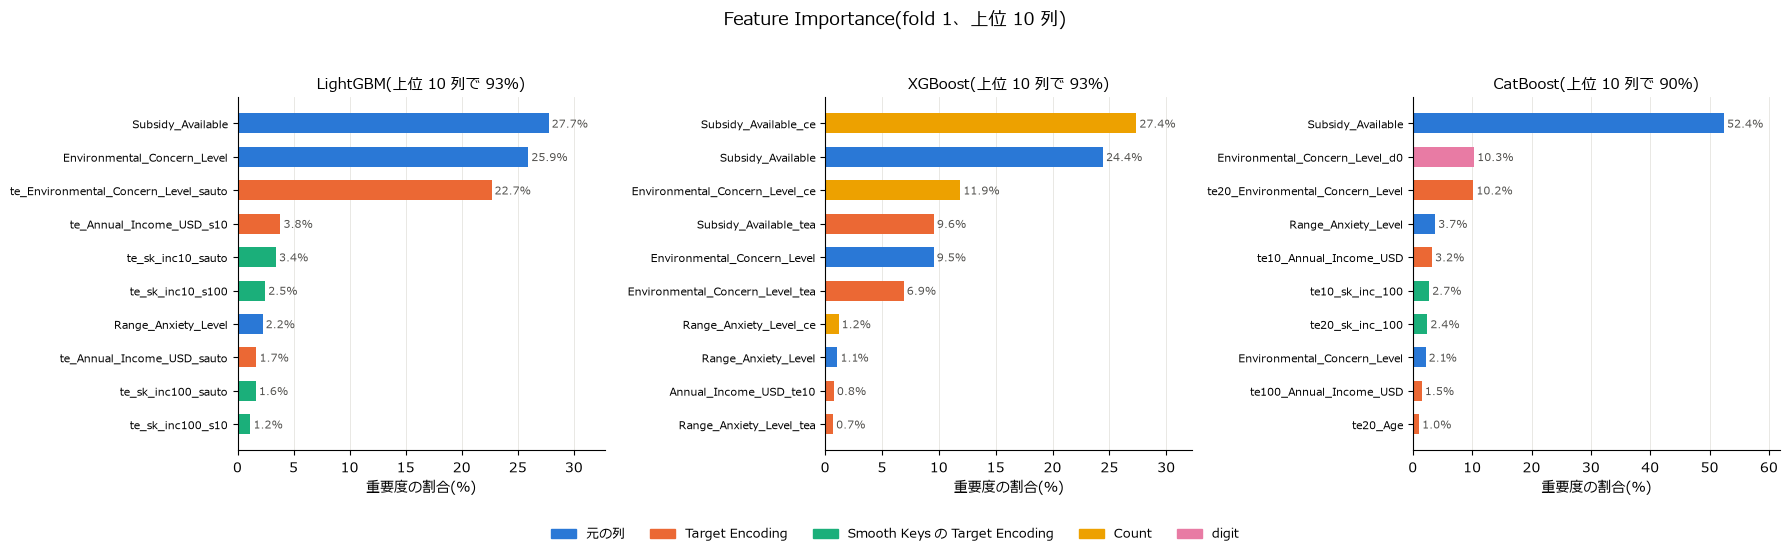

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

for font in ["Meiryo", "Yu Gothic", "MS Gothic"]:   # 日本語を表示できるフォント
    if font in {f.name for f in matplotlib.font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = font
        break

# 列の種類ごとに色を固定する(どのモデルの図でも同じ種類は同じ色)
KINDS = ["元の列", "Target Encoding", "Smooth Keys の Target Encoding", "Count", "digit"]
COLORS = dict(zip(KINDS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))
TITLES = {"lgbm": "LightGBM", "xgb": "XGBoost", "catboost": "CatBoost"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (m, share) in zip(axes, IMP.items()):
    top = share.head(10)[::-1]                       # 上から大きい順に並べる
    ax.barh(top.index, top.values, color=[COLORS[fi.kind_of(c)] for c in top.index], height=0.6)
    for i, v in enumerate(top.values):
        ax.text(v + top.max() * 0.01, i, f"{v:.1f}%", va="center", fontsize=8, color="#52514e")
    ax.set_title(f"{TITLES[m]}(上位 10 列で {share.head(10).sum():.0f}%)", fontsize=11)
    ax.set_xlabel("重要度の割合(%)")
    ax.set_xlim(0, top.max() * 1.18)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)

fig.legend(handles=[Patch(color=COLORS[k], label=k) for k in KINDS], loc="lower center", ncol=5, frameon=False, fontsize=9)
fig.suptitle("Feature Importance(fold 1、上位 10 列)", fontsize=13)
fig.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()

In [ ]:
# 図と同じ値の表(列の種類つき)
rows = [[TITLES[m], rank, col, round(pct, 2), fi.kind_of(col)]
        for m, share in IMP.items() for rank, (col, pct) in enumerate(share.head(10).items(), 1)]
print(pd.DataFrame(rows, columns=["モデル", "順位", "列", "割合(%)", "種類"]).to_string(index=False))

     モデル  順位                                    列  割合(%)                            種類
LightGBM   1                    Subsidy_Available  27.74                           元の列
LightGBM   2          Environmental_Concern_Level  25.93                           元の列
LightGBM   3 te_Environmental_Concern_Level_sauto  22.65               Target Encoding
LightGBM   4             te_Annual_Income_USD_s10   3.83               Target Encoding
LightGBM   5                    te_sk_inc10_sauto   3.43 Smooth Keys の Target Encoding
LightGBM   6                     te_sk_inc10_s100   2.46 Smooth Keys の Target Encoding
LightGBM   7                  Range_Anxiety_Level   2.24                           元の列
LightGBM   8           te_Annual_Income_USD_sauto   1.69               Target Encoding
LightGBM   9                   te_sk_inc100_sauto   1.63 Smooth Keys の Target Encoding
LightGBM  10                     te_sk_inc100_s10   1.15 Smooth Keys の Target Encoding
 XGBoost   1                 Subsidy_Availa

### 重要度から読み取れること(重要度は「相関」ではない)

重要度は「**モデルがその列をどれだけ分割に使ったか**」で、目的変数との相関(一緒に動く強さ)や、因果とは別物。次の点に注意して読む。

| 読み取れること | 注意点 |
|---|---|
| **補助金の有無と環境意識の2つ(元の列・Count・Target Encoding の形を合わせて)で、重要度の 7〜9 割を占める**。購入するかは大半がこの2つで決まり、残りの 1〜3 割の細かい差でスコアを競っている | 最初に分割に使われた列ほど損失を大きく減らすので、重要度が大きく出やすい。「2 列だけで十分」という意味ではない |
| **その次は年収の Target Encoding と Smooth Keys**(年収を粗く丸めたキー)。3 モデルとも、年収の細部を購入率の形で使っている | 平滑化の違う列(auto / 10 / 100)に重要度が分かれる。同じ情報を持つ列が並ぶと、1 列あたりの重要度は小さく見える |
| **同じ情報の形が違う列で、重要度を分け合う**。XGBoost は補助金を元の列・Count・Target Encoding の3つで使い、CatBoost は元の列だけで 5 割を使う | どの形が選ばれるかはモデルの仕組みと偶然で決まる。形ごとの重要度を比べて「どれが良い列か」を決めることはできない |
| **重要度が小さい列が不要とは限らない** | 年齢などを落とすと -0.00044 と明確に悪化した(9 章)。残りの 1〜3 割の差が順位を決めるので、小さい列ほど効いていることがある |

**まとめ**: 重要度は「モデルが何を手がかりにしているか」の地図で、列を削る根拠にはならない。
伸びしろは上位 2 列ではなく、**残りの 1〜3 割(年収の細部など)をどれだけ正確に表せるか**にある。